# Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

##  Setup and Data Loading.

In [1]:
# !pip install scipy statsmodels

In [2]:
# Core libraries
import pandas as pd
import numpy as np

In [3]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Statistical tests
from scipy.stats import chi2_contingency, pearsonr, spearmanr
import statsmodels.api as sm

In [5]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')

In [6]:
# Load dataset
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7000,15308,21.9900,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7000,98099,23.9900,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7000,15308,21.9900,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7000,7205,31.9900,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6000,1881,17.9900,False,0,Hi-Fi Speakers


###  Quick Data Quality Check

In [7]:
# Basic structure and missing values
print(df.info())

missing_summary = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ['column', 'missing_percentage']
missing_summary.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB
None


,column,missing_percentage
0,uid,0.0000
1,asin,0.0000
2,title,0.0000
3,stars,0.0000
4,reviews,0.0000
5,price,0.0000
6,isBestSeller,0.0000
7,boughtInLastMonth,0.0000
8,category,0.0000


###  Column Detection and Cleaning


In [8]:
def find_column(dataframe, candidates):
    """Find a column by comparing lowercase column names against possible candidates."""
    lower_to_original = {col.lower(): col for col in dataframe.columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None

# Try to identify the required columns
category_col = find_column(df, ['category', 'category_name', 'main_category', 'product_category'])
price_col = find_column(df, ['price', 'actual_price', 'discount_price'])
stars_col = find_column(df, ['stars', 'rating', 'ratings'])
bestseller_col = find_column(df, ['isBestSeller', 'is_best_seller', 'best_seller', 'bestseller'])
category_id_col = find_column(df, ['category_id', 'categoryid'])

print('Detected columns:')
print(f'Category: {category_col}')
print(f'Category ID: {category_id_col}')
print(f'Price: {price_col}')
print(f'Stars/Rating: {stars_col}')
print(f'Best seller: {bestseller_col}')

Detected columns:
Category: category
Category ID: None
Price: price
Stars/Rating: stars
Best seller: isBestSeller


In [9]:
# Clean price and rating columns if they are stored as strings
for col in [price_col, stars_col]:
    if df[col].dtype == 'object':
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('£', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.extract(r'(\d+\.?\d*)')[0]
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
# Normalize best-seller column into boolean where possible
if df[bestseller_col].dtype == 'object':
    df[bestseller_col] = (
        df[bestseller_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'true': True, 'false': False, 'yes': True, 'no': False, '1': True, '0': False})
        .fillna(df[bestseller_col])
    )

In [11]:
# Keep rows with the minimum required fields for the lab
df_lab = df.dropna(subset=[category_col, price_col, stars_col, bestseller_col]).copy()

print(f'Original rows: {len(df):,}')
print(f'Rows available for lab after basic cleaning: {len(df_lab):,}')
df_lab[[category_col, price_col, stars_col, bestseller_col]].head()

Original rows: 2,443,651
Rows available for lab after basic cleaning: 2,443,651


,category,price,stars,isBestSeller
0,Hi-Fi Speakers,21.9900,4.7000,False
1,Hi-Fi Speakers,23.9900,4.7000,True
2,Hi-Fi Speakers,21.9900,4.7000,False
3,Hi-Fi Speakers,31.9900,4.7000,False
4,Hi-Fi Speakers,17.9900,4.6000,False


---
# Part 1: Analyzing Best-Seller Trends Across Product Categories

Objective: Understand the relationship between product categories and their best-seller status.


## 1.1 Crosstab Analysis

In [12]:
#  crosstab between the product category and the isBestSeller status.
category_bestseller_ct = pd.crosstab(df_lab[category_col], df_lab[bestseller_col])
category_bestseller_ct.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [13]:
# Calculate best-seller proportion by category

if True in category_bestseller_ct.columns:
    best_col = True
else:
   
    best_col = category_bestseller_ct.columns[-1]

bestseller_proportion = (
    category_bestseller_ct
    .assign(total=category_bestseller_ct.sum(axis=1))
    .assign(best_seller_rate=lambda x: x[best_col] / x['total'])
    .sort_values('best_seller_rate', ascending=False)
)

bestseller_proportion.head(15)

isBestSeller,False,True,total,best_seller_rate
category,,,,
Grocery,9008,556,9564,0.0581
Smart Home Security & Lighting,98,6,104,0.0577
Health & Personal Care,9017,552,9569,0.0577
Mobile Phone Accessories,248,11,259,0.0425
Power & Hand Tools,8353,306,8659,0.0353
"Billiard, Snooker & Pool",241,8,249,0.0321
Pet Supplies,9152,285,9437,0.0302
Home Brewing & Wine Making,239,7,246,0.0285
Mirrors,243,7,250,0.0280


### Business Q1 Answer

 The categories with the highest best-seller prevalence are not necessarily the categories with the largest number of products. This suggests that best-seller concentration should be interpreted together with category size, because a small category can show a high best-seller rate with relatively few products.

## 1.2 Statistical Tests: Chi-Square and Cramér’s V

In [14]:
# Chi-square test
chi2_stat, chi2_p_value, dof, expected = chi2_contingency(category_bestseller_ct)

print(f'Chi-square statistic: {chi2_stat:,.4f}')
print(f'p-value: {chi2_p_value:.6f}')
print(f'Degrees of freedom: {dof}')

if chi2_p_value < 0.05:
    print('Result: Reject H0. Best-seller status is not independent from product category.')
else:
    print('Result: Fail to reject H0. There is not enough evidence of association between category and best-seller status.')

Chi-square statistic: 36,540.2027
p-value: 0.000000
Degrees of freedom: 295
Result: Reject H0. Best-seller status is not independent from product category.


In [15]:
def cramers_v(confusion_matrix):
    """Calculate Cramér's V for a contingency table."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cramers_v_value = cramers_v(category_bestseller_ct)
print(f"Cramér's V: {cramers_v_value:.4f}")

if cramers_v_value < 0.1:
    strength = 'very weak'
elif cramers_v_value < 0.3:
    strength = 'weak'
elif cramers_v_value < 0.5:
    strength = 'moderate'
else:
    strength = 'strong'

print(f'Association strength: {strength}')

Cramér's V: 0.1223
Association strength: weak


### Business Q2 Answer

If the p-value is below 0.05, category and best-seller status are statistically associated. However, if Cramér’s V is low, the relationship may be statistically significant but weak from a business perspective. This means category matters, but it may not be the only or strongest driver of best-seller performance.

## 1.3 Visualization: Stacked Bar Chart

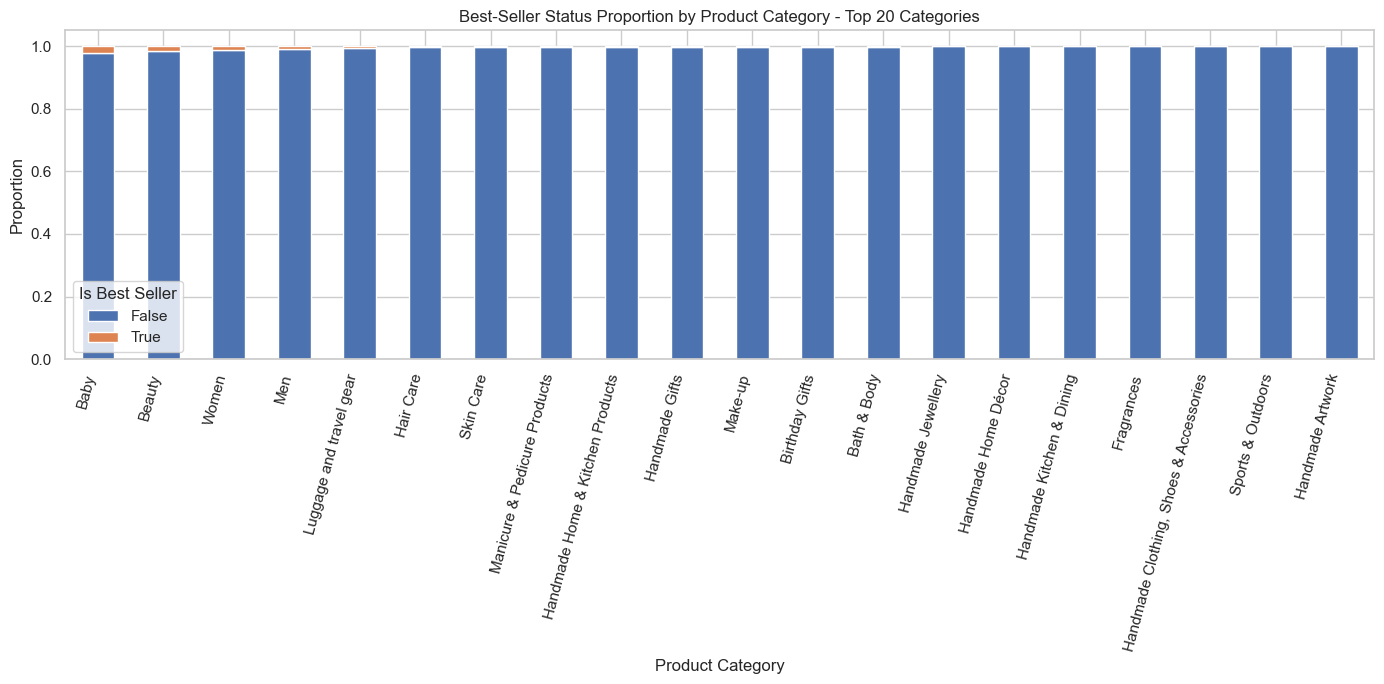

In [16]:
# Use top categories by product count for readability
top_20_categories = df_lab[category_col].value_counts().head(20).index
part1_top = df_lab[df_lab[category_col].isin(top_20_categories)].copy()

stacked_data = pd.crosstab(
    part1_top[category_col],
    part1_top[bestseller_col],
    normalize='index'
).sort_values(by=best_col, ascending=False)

ax = stacked_data.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Best-Seller Status Proportion by Product Category - Top 20 Categories')
plt.xlabel('Product Category')
plt.ylabel('Proportion')
plt.xticks(rotation=75, ha='right')
plt.legend(title='Is Best Seller')
plt.tight_layout()
plt.show()

---
# Part 2: Exploring Product Prices and Ratings Across Categories

Objective: Investigate how different product categories influence product prices.

## 2.1 Preliminary Step: Remove Price Outliers using IQR

In [17]:
def remove_outliers_iqr(dataframe, column, scale=1.5):
    """Remove outliers based on the IQR method and return the cleaned dataframe plus bounds."""
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - scale * iqr
    upper_bound = q3 + scale * iqr
    
    cleaned = dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)].copy()
    return cleaned, lower_bound, upper_bound

# Remove price outliers
df_no_price_outliers, lower_price_bound, upper_price_bound = remove_outliers_iqr(df_lab, price_col)

print(f'Lower price bound: {lower_price_bound:,.2f}')
print(f'Upper price bound: {upper_price_bound:,.2f}')
print(f'Rows before removing price outliers: {len(df_lab):,}')
print(f'Rows after removing price outliers: {len(df_no_price_outliers):,}')
print(f'Removed rows: {len(df_lab) - len(df_no_price_outliers):,}')

Lower price bound: -44.01
Upper price bound: 99.99
Rows before removing price outliers: 2,443,651
Rows after removing price outliers: 2,115,963
Removed rows: 327,688


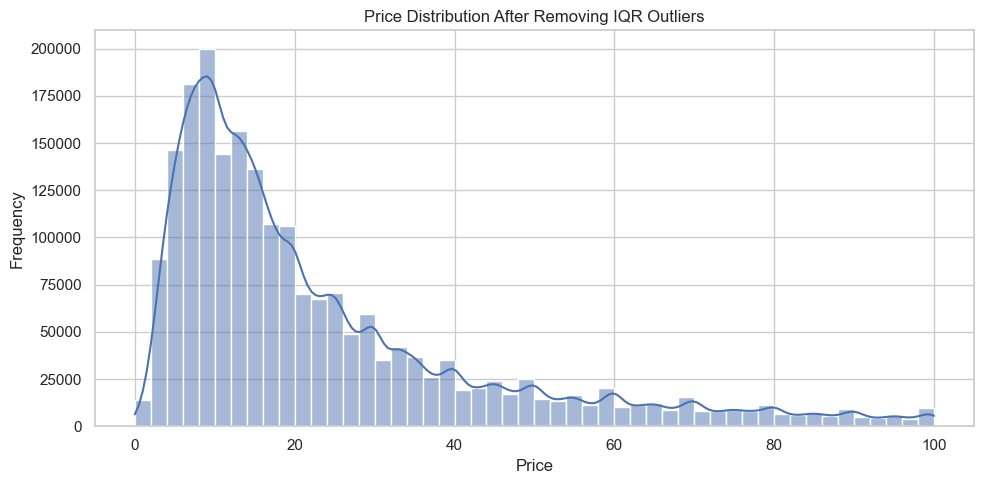

In [18]:
# Quick comparison of price distribution before and after outlier removal
plt.figure(figsize=(10, 5))
sns.histplot(df_no_price_outliers[price_col], bins=50, kde=True)
plt.title('Price Distribution After Removing IQR Outliers')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 2.2 Violin Plot: Price Distribution Across Top 20 Categories

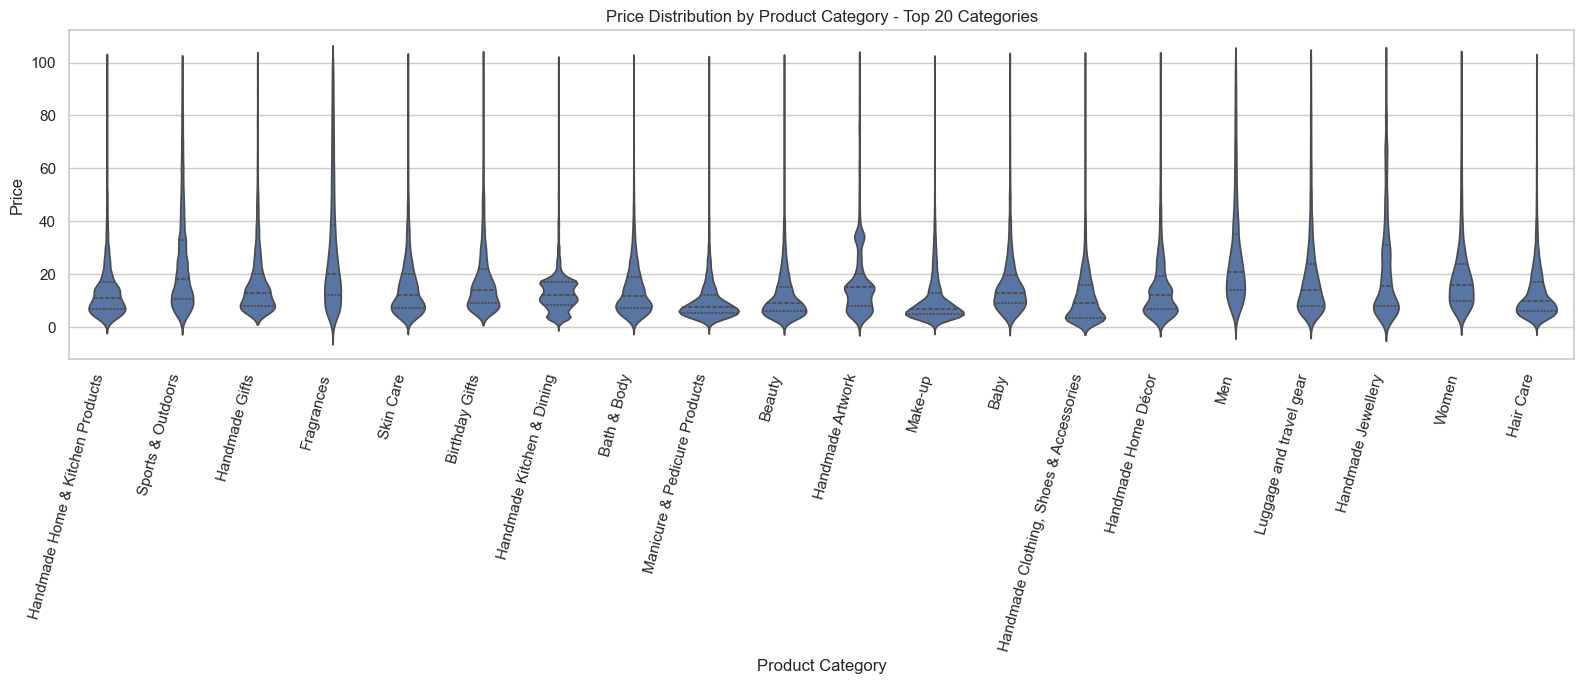

In [19]:
top_20_categories_clean = df_no_price_outliers[category_col].value_counts().head(20).index
violin_df = df_no_price_outliers[df_no_price_outliers[category_col].isin(top_20_categories_clean)].copy()

plt.figure(figsize=(16, 7))
sns.violinplot(data=violin_df, x=category_col, y=price_col, inner='quartile')
plt.title('Price Distribution by Product Category - Top 20 Categories')
plt.xlabel('Product Category')
plt.ylabel('Price')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Category with the highest median price across ALL categories, not just top 20
median_price_by_category = (
    df_no_price_outliers
    .groupby(category_col)[price_col]
    .median()
    .sort_values(ascending=False)
)

print('Top 10 categories by median price:')
display(median_price_by_category.head(10))

highest_median_price_category = median_price_by_category.index[0]
print(f'Category with highest median price: {highest_median_price_category}')

Top 10 categories by median price:


category
Desktop PCs              74.0000
Boxing Shoes             69.7900
Tablets                  69.0000
Graphics Cards           68.5400
Motherboards             67.9200
Made in Italy Handmade   64.0000
Digital Frames           63.9000
Streaming Clients        62.6800
Golf Shoes               62.3900
Ski Helmets              61.3300
Name: price, dtype: float64

Category with highest median price: Desktop PCs


### Business Q3 Answer

The category with the highest median price is Desktop PCs. This suggests that products in this category usually occupy a higher price segment, making it potentially relevant for premium positioning, margin analysis, or advertising investment.

## 2.3 Bar Chart: Average Price for Top 10 Categories by Count

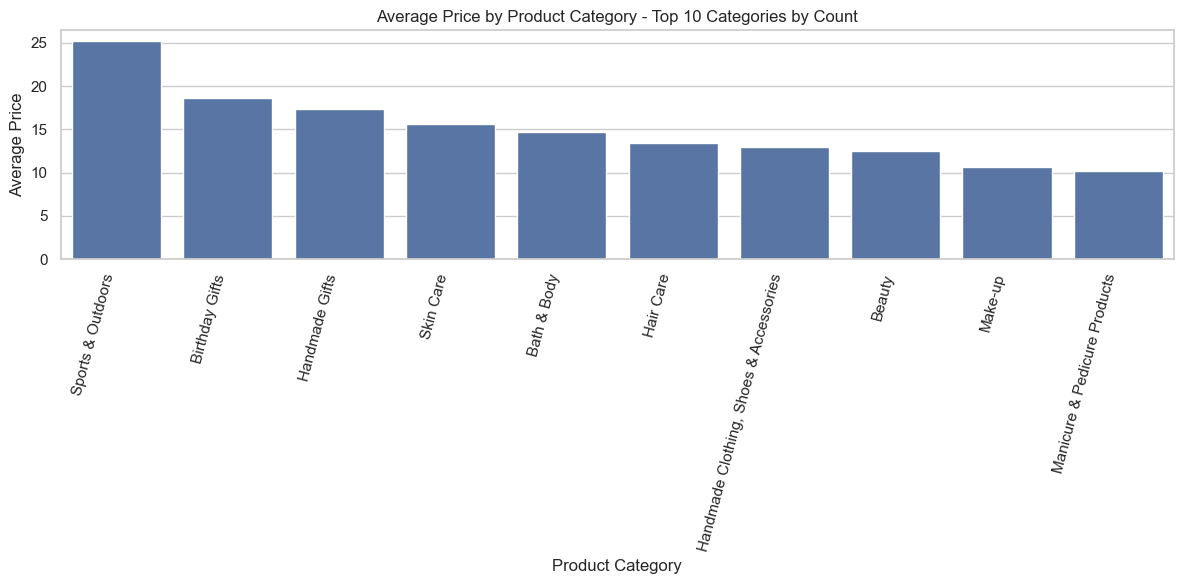

Top 10 categories by average price across all categories:


category
Motherboards        68.7724
Boxing Shoes        67.4178
Desktop PCs         66.9156
Tablets             66.5530
Graphics Cards      65.1035
Digital Frames      60.7451
Streaming Clients   60.2418
Hockey Shoes        60.0948
Computer Cases      58.3399
Skiing Poles        57.8678
Name: price, dtype: float64

Category with highest average price: Motherboards


In [21]:
top_10_categories_clean = df_no_price_outliers[category_col].value_counts().head(10).index
bar_df = df_no_price_outliers[df_no_price_outliers[category_col].isin(top_10_categories_clean)].copy()

avg_price_top_10 = (
    bar_df
    .groupby(category_col)[price_col]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_top_10.index, y=avg_price_top_10.values)
plt.title('Average Price by Product Category - Top 10 Categories by Count')
plt.xlabel('Product Category')
plt.ylabel('Average Price')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

# Highest average price across ALL categories, not only top 10
avg_price_all_categories = (
    df_no_price_outliers
    .groupby(category_col)[price_col]
    .mean()
    .sort_values(ascending=False)
)

print('Top 10 categories by average price across all categories:')
display(avg_price_all_categories.head(10))
print(f'Category with highest average price: {avg_price_all_categories.index[0]}')

### Business Q4 Answer
 
 The category commanding the highest average price is Motherboards. From a business perspective, this category may represent a higher-value segment, but average price should be interpreted carefully because it can still be influenced by remaining extreme values or low product counts.

## 2.4 Box Plot: Product Ratings by Top 10 Categories

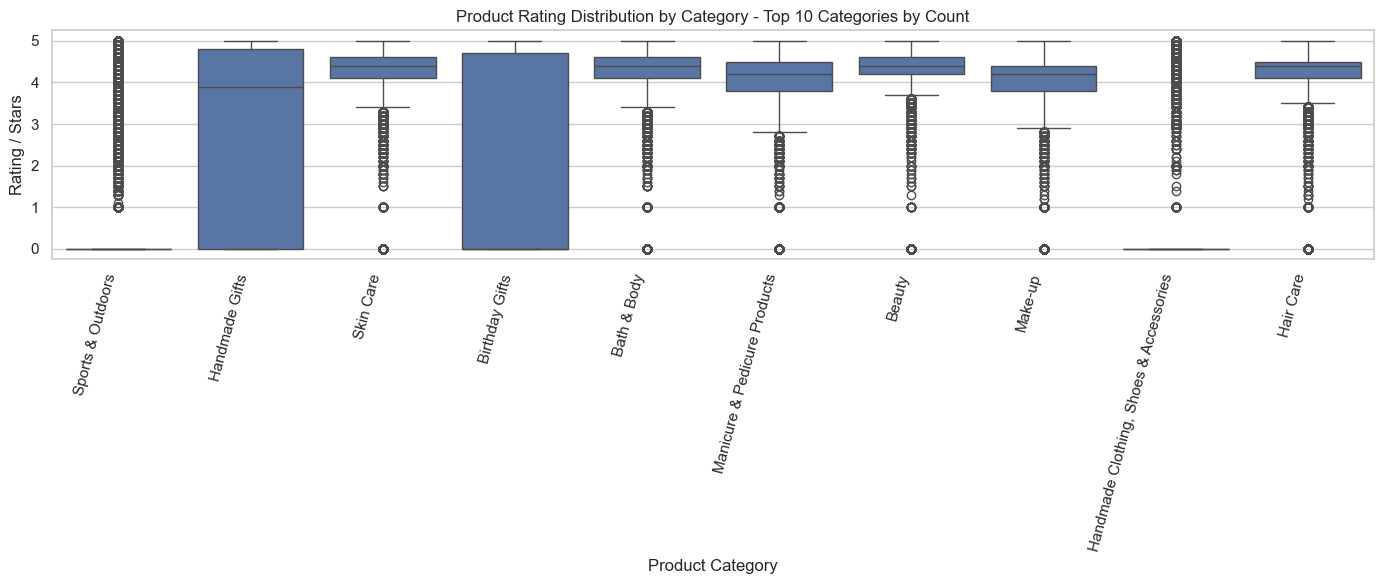

In [22]:
box_df = df_no_price_outliers[df_no_price_outliers[category_col].isin(top_10_categories_clean)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=box_df, x=category_col, y=stars_col)
plt.title('Product Rating Distribution by Category - Top 10 Categories by Count')
plt.xlabel('Product Category')
plt.ylabel('Rating / Stars')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [23]:
# Category with highest median rating across ALL categories
median_rating_by_category = (
    df_no_price_outliers
    .groupby(category_col)[stars_col]
    .median()
    .sort_values(ascending=False)
)

print('Top 10 categories by median rating:')
display(median_rating_by_category.head(10))
print(f'Category with highest median rating: {median_rating_by_category.index[0]}')

Top 10 categories by median rating:


category
Computer Memory                4.7000
Beer, Wine & Spirits           4.6000
Building & Construction Toys   4.6000
Office Paper Products          4.6000
Kids' Play Figures             4.6000
Laptop Accessories             4.6000
Hobbies                        4.6000
Luxury Food & Drink            4.6000
Soft Toys                      4.5000
Boxes & Organisers             4.5000
Name: stars, dtype: float64

Category with highest median rating: Computer Memory


### Business Q5 Answer

The category with the highest median rating is Computer Memory. This may indicate stronger customer satisfaction, better product-market fit, or a category where expectations are being met more consistently.

---
# Part 3: Investigating the Interplay Between Product Prices and Ratings

Objective: Analyze how product ratings (stars) correlate with product prices.

## 3.1 Correlation Between Price and Stars

In [24]:
# Drop missing values for correlation analysis
corr_df = df_no_price_outliers[[price_col, stars_col]].dropna().copy()

pearson_corr, pearson_p = pearsonr(corr_df[price_col], corr_df[stars_col])
spearman_corr, spearman_p = spearmanr(corr_df[price_col], corr_df[stars_col])

print(f'Pearson correlation: {pearson_corr:.4f}')
print(f'Pearson p-value: {pearson_p:.6f}')
print('---')
print(f'Spearman correlation: {spearman_corr:.4f}')
print(f'Spearman p-value: {spearman_p:.6f}')

if abs(pearson_corr) < 0.1:
    print('Pearson interpretation: very weak or almost no linear relationship.')
elif abs(pearson_corr) < 0.3:
    print('Pearson interpretation: weak linear relationship.')
elif abs(pearson_corr) < 0.5:
    print('Pearson interpretation: moderate linear relationship.')
else:
    print('Pearson interpretation: strong linear relationship.')

Pearson correlation: -0.0777
Pearson p-value: 0.000000
---
Spearman correlation: -0.0668
Spearman p-value: 0.000000
Pearson interpretation: very weak or almost no linear relationship.


### Business Q6 Answer

The correlation between price and rating is very weak or almost no linear relationship. This suggests that higher prices do not necessarily translate into higher customer ratings. From a business perspective, price alone may not be a strong predictor of customer satisfaction.

## 3.2 Scatter Plot: Price vs Rating

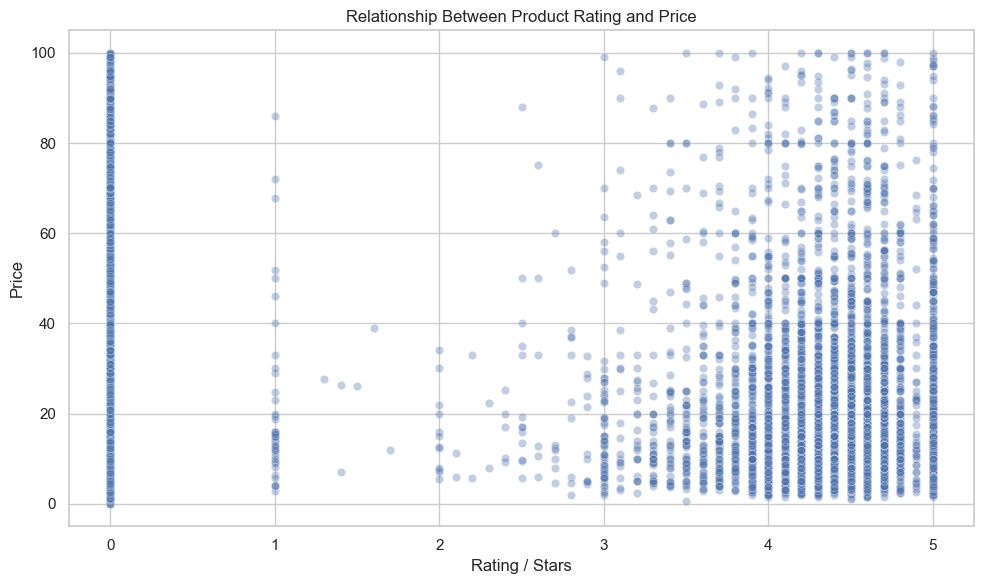

In [25]:
# Sampling improves plot readability and performance for large datasets
sample_size = min(10000, len(df_no_price_outliers))
scatter_sample = df_no_price_outliers.sample(sample_size, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_sample, x=stars_col, y=price_col, alpha=0.35)
plt.title('Relationship Between Product Rating and Price')
plt.xlabel('Rating / Stars')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

### Scatter Plot Interpretation

The scatter plot does not show a strong linear pattern between rating and price. Most products appear concentrated around common rating values, while price varies within those rating groups. This suggests that customer rating is likely influenced by factors beyond price, such as product quality, expectations, reviews volume, delivery experience, or brand trust.

## 3.3 Correlation Heatmap for Numerical Variables

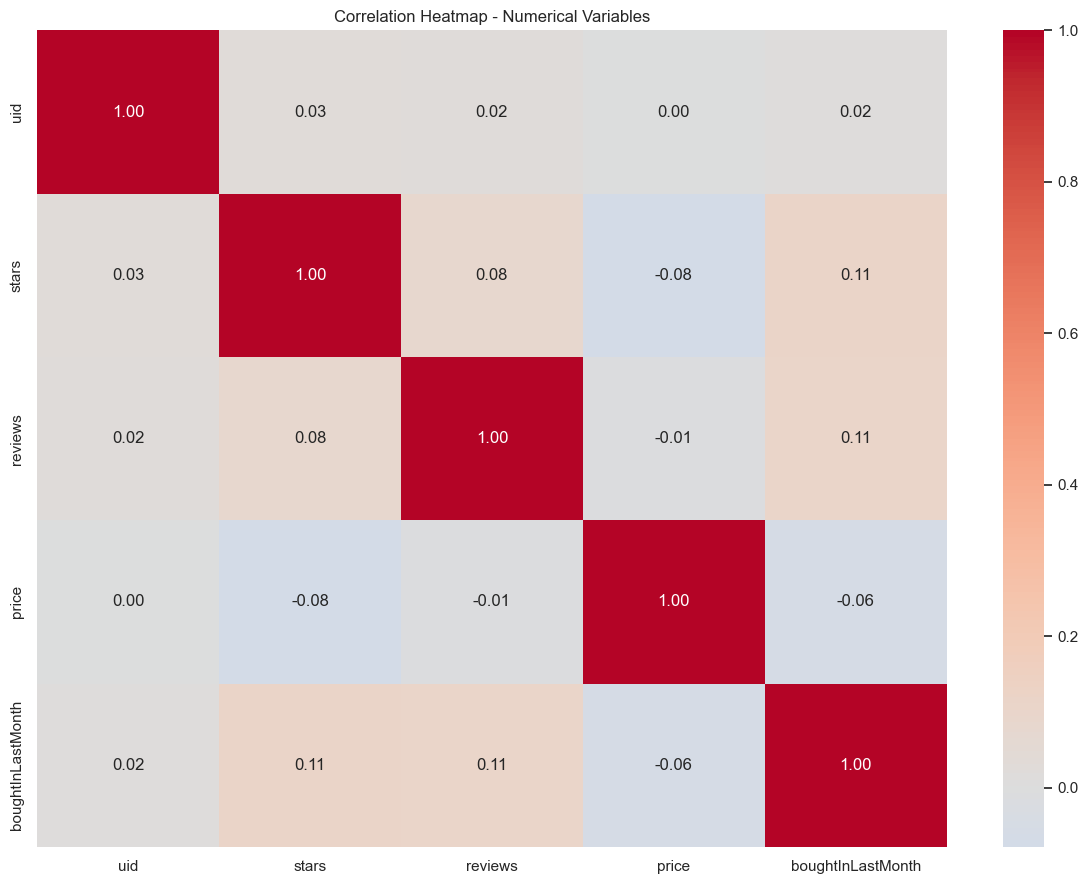

In [26]:
# Select numerical variables from the cleaned dataframe
numeric_df = df_no_price_outliers.select_dtypes(include='number').copy()

# Optional: remove columns with too many missing values or only one unique value
numeric_df = numeric_df.loc[:, numeric_df.isna().mean() < 0.5]
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numerical Variables')
plt.tight_layout()
plt.show()

## 3.4 QQ Plot: Does Price Follow a Normal Distribution?

<Figure size 700x700 with 0 Axes>

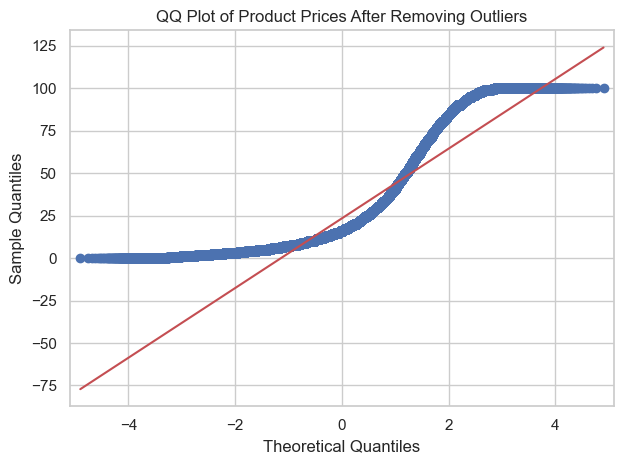

In [27]:
plt.figure(figsize=(7, 7))
sm.qqplot(df_no_price_outliers[price_col].dropna(), line='s')
plt.title('QQ Plot of Product Prices After Removing Outliers')
plt.tight_layout()
plt.show()

### Business Q7 Answer

If the points in the QQ plot deviate strongly from the reference line, product prices do not follow a normal distribution. This is common in e-commerce pricing, where many products are low or mid-priced and fewer products sit in higher price ranges.

---
# Final Business-Centric Report

## Executive Summary

This analysis explored how Amazon UK product category relates to best-seller status, pricing, and ratings. The goal was to identify patterns that could help sellers, category managers, or marketplace analysts make more informed decisions.

## Business Recommendations

- Categories with high best-seller rates could be studied for product positioning, pricing, and customer demand signals.
- Higher-priced categories may deserve separate margin and competition analysis.
- If price and rating are weakly correlated, sellers should avoid assuming that premium pricing alone leads to better customer perception.
- Categories with high ratings but moderate prices may represent strong value-for-money opportunities.

## Limitations

- Best-seller status is binary and may not capture sales volume fully.
- Ratings can be biased by the number of reviews.
- Product categories with small counts can show extreme proportions.
- Removing price outliers improves readability but may exclude strategically important premium products.

## Next Steps

- Include review count to weight ratings more realistically.
- Analyze brand-level patterns if brand data is available.
- Compare results with and without outliers.
- Build a simple predictive model to estimate best-seller likelihood.

---
# Bonus: Repeat Key Analysis Without Removing Price Outliers

This section helps compare whether price outliers change the conclusions.

In [28]:
# Bonus: correlation without removing price outliers
bonus_corr_df = df_lab[[price_col, stars_col]].dropna().copy()

bonus_pearson_corr, bonus_pearson_p = pearsonr(bonus_corr_df[price_col], bonus_corr_df[stars_col])
bonus_spearman_corr, bonus_spearman_p = spearmanr(bonus_corr_df[price_col], bonus_corr_df[stars_col])

print('Without removing price outliers')
print(f'Pearson correlation: {bonus_pearson_corr:.4f}')
print(f'Pearson p-value: {bonus_pearson_p:.6f}')
print('---')
print(f'Spearman correlation: {bonus_spearman_corr:.4f}')
print(f'Spearman p-value: {bonus_spearman_p:.6f}')

Without removing price outliers
Pearson correlation: -0.1249
Pearson p-value: 0.000000
---
Spearman correlation: -0.1332
Spearman p-value: 0.000000


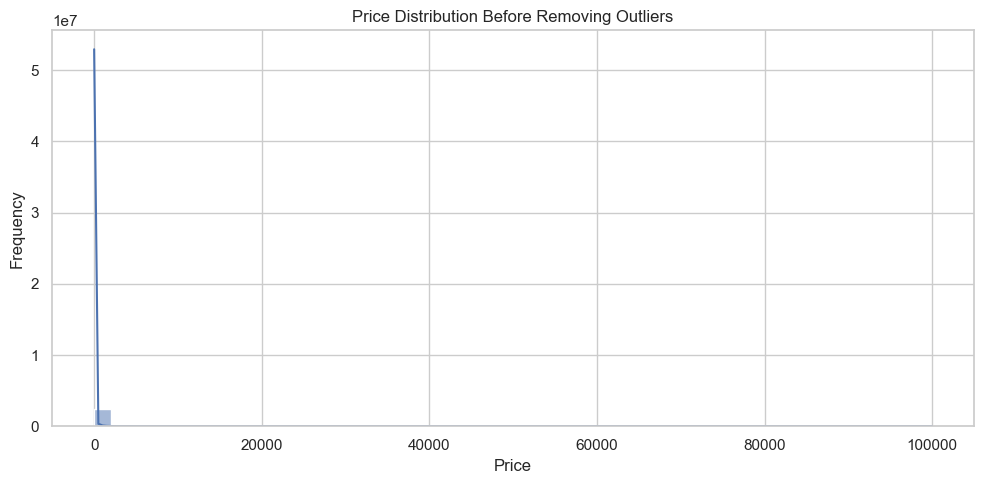

In [29]:
# Bonus: price distribution without removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(df_lab[price_col].dropna(), bins=50, kde=True)
plt.title('Price Distribution Before Removing Outliers')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Bonus Insight

When outliers are included, the price distribution becomes more skewed and visual interpretation becomes harder. If correlation changes noticeably, this suggests that extreme prices influence the relationship between price and rating. For business reporting, both views are useful: the cleaned version shows mainstream product behavior, while the outlier-inclusive version highlights premium or unusual products.